# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [49]:
# Lectura datos, relación variables, mapas de correlación...

In [50]:
# Utiliza todas las celdas que necesites...

In [51]:
Muebles = pd.read_csv(r"C:\Users\Eneko\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\1-Supervisado\1-Regression\3-Regularization\ejercicios\data\Advertising.csv")

In [52]:
Muebles.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newpaper    200 non-null    str    
 4   sales       200 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 7.9 KB


In [53]:
Muebles.head()

,Unnamed: 0,TV,radio,newpaper,sales
0,0,230.1,37.8,6s9.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0


In [54]:
# Eliminar la columna de índice duplicado
Muebles = Muebles.drop(columns=['Unnamed: 0'])

# Limpiar el string "s" en la columna 'newpaper'
# Usamos str.replace con una expresión regular para dejar solo números y puntos
Muebles['newpaper'] = Muebles['newpaper'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# Convertir a numérico
Muebles['newpaper'] = pd.to_numeric(Muebles['newpaper'], errors='coerce')

Muebles.head()
Muebles.dtypes

TV          float64
radio       float64
newpaper    float64
sales       float64
dtype: object

In [55]:
Muebles.head()

,TV,radio,newpaper,sales
0,230.1,37.8,69.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0


## Modelado

In [56]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

In [57]:
# Utiliza todas las celdas que necesites...

In [58]:

X = Muebles[['TV', 'radio', 'newpaper']]
y = Muebles['sales']

# Dividir en set de entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

# Verificar las dimensiones
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (160, 3)
Forma de y_train: (160,)


In [59]:
# Definir los modelos
modelos = {"Lineal Simple": LinearRegression(),"Ridge (L2)": Ridge(alpha=1.0),"Lasso (L1)": Lasso(alpha=1.0)}

# Entrenar y evaluar
resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    resultados[nombre] = rmse

# 3. Mostrar resultados ordenados de mejor a peor
for nombre, error in sorted(resultados.items(), key=lambda x: x[1]):
    print(f"{nombre}: RMSE = {error:.4f}")

Lasso (L1): RMSE = 1642.5608
Ridge (L2): RMSE = 1642.5661
Lineal Simple: RMSE = 1642.6028


In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [62]:
metricas = []

# Convertimos el array escalado a DataFrame con los nombres originales
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=['TV', 'radio', 'newpaper'])

for nombre, modelo in modelos.items():
    # Ahora pasamos el DataFrame para que coincida con el formato de entrenamiento
    preds = modelo.predict(X_test_scaled_df)
    metricas.append(evaluar_modelo(nombre, y_test, preds))

df_metricas = pd.DataFrame(metricas)
print(df_metricas)

          Modelo           MAE      MAPE          RMSE
0  Lineal Simple  10317.997608  0.744327  11521.154050
1     Ridge (L2)  10317.893707  0.744317  11521.062508
2     Lasso (L1)  10317.946196  0.744322  11521.109230


In [63]:
from sklearn.linear_model import ElasticNetCV

Peso óptimo (l1_ratio): 1.0
Alpha óptimo: 114.9756995397738


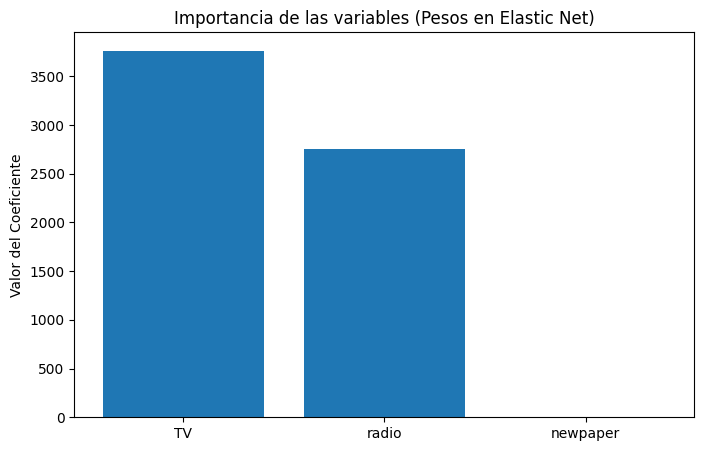

In [ ]:
# l1_ratio: 0.1 (más Ridge) hasta 1.0 (Lasso puro)
en_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     alphas=np.logspace(-4, 4, 100), cv=5)

# 2. Entrenar (usando los datos escalados)
en_cv.fit(X_train_scaled, y_train)

# 3. Resultados finales
print(f"Peso óptimo (l1_ratio): {en_cv.l1_ratio_}")
print(f"Alpha óptimo: {en_cv.alpha_}")

# 4. Gráfica de coeficientes para ver el peso de cada variable
plt.figure(figsize=(8, 5))
plt.bar(X.columns, en_cv.coef_)
plt.title('Importancia de las variables (Pesos en Elastic Net)')
plt.ylabel('Valor del Coeficiente')
plt.show()

# El peso al ser 1 quiere decir que nos vale con Lasso. TV es lo que más peso tiene mientras que newpaper no tiene influencia alguna y solo es ruido.

### Modelos Polinómicos

In [69]:
# Convertir a DataFrame
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=['TV', 'radio', 'newpaper'])

# Usar .values para pasar solo los números
y_pred_en = en_cv.predict(X_test_scaled_df.values)

# Importar métricas y calcular
from sklearn.metrics import mean_absolute_error, r2_score

mae_final = mean_absolute_error(y_test, y_pred_en)
r2_final = r2_score(y_test, y_pred_en)

print(f"R2 Final: {r2_final:.4f}")
print(f"MAE Final: {mae_final:.4f}")

R2 Final: 0.9100
MAE Final: 1300.1062


In [70]:
# Ver los pesos reales que el modelo asignó
coeficientes = pd.DataFrame(en_cv.coef_, index=X.columns, columns=['Peso'])
print(coeficientes)

                 Peso
TV        3764.061958
radio     2749.755071
newpaper    -0.000000


## Resultados

In [66]:
# Interpreta, resume y destaca los puntos importantes de los resultados.

In [67]:
# Utiliza todas las celdas que necesites...

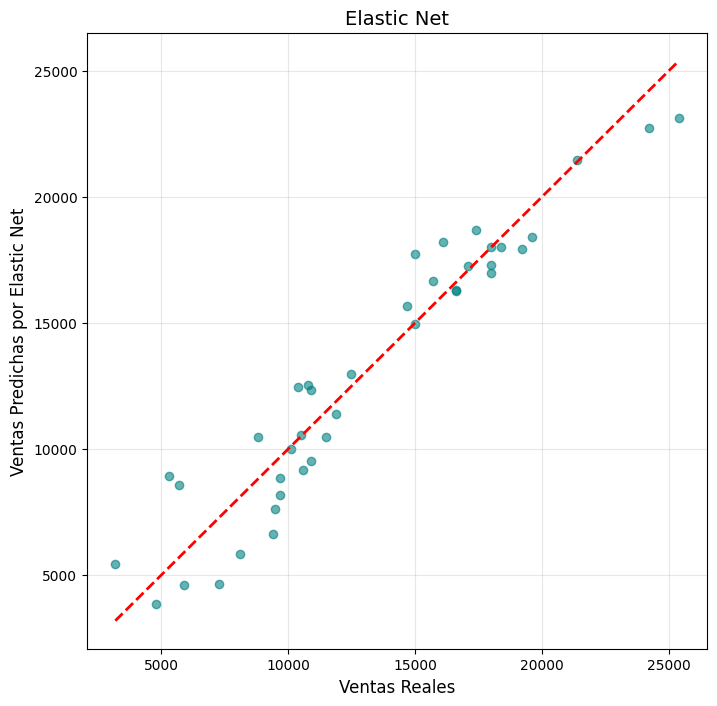

In [68]:
# Graficar Realidad vs Predicción
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_en, alpha=0.6, color='teal')

# Línea de referencia (donde Real = Predicción)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', lw=2, linestyle='--')

plt.title('Elastic Net', fontsize=14)
plt.xlabel('Ventas Reales', fontsize=12)
plt.ylabel('Ventas Predichas por Elastic Net', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()